## **ДИСКУРС-АНАЛИЗ СОЛИДАРНОСТИ В ДЕКЛАРАЦИЯХ G77**

In [1]:
import os
import re
from pathlib import Path
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import re

try:
    import nltk
except Exception:
    nltk = None

import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer

from scipy import stats
from scipy.stats import spearmanr, kendalltau

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 250)

## Загрузка корпуса

In [3]:
G77 = "g77data_translated.csv"

#читаем таблицу
df1 = pd.read_csv(G77)

translated_series = df1.get("translated_text", pd.Series(index=df1.index, dtype="object"))
original_series = df1.get("text", pd.Series(index=df1.index, dtype="object"))

translated_clean = translated_series.fillna("").astype(str).str.strip()
original_clean = original_series.fillna("").astype(str).str.strip()

#если перевод есть и непустой - берём его, если нет - берём оригинал
use_translation = (~translated_clean.eq("")) & (~translated_clean.str.lower().isin({"nan", "none"}))
combined_text = np.where(use_translation, translated_clean, original_clean)
combined_text = pd.Series(combined_text, index=df1.index).fillna("").astype(str).str.strip()

#создаём бд
df = pd.DataFrame()

#год: извлекаем 4 цифры из идентификатора
df["year"] = pd.to_numeric(df1["id"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce",)

#заголовок
df["title"] = df1["names"].fillna("").astype(str)

df["text"] = combined_text
df["url"] = df1["links"].fillna("").astype(str)

#удаляем строки без года или пустого текста
df = df.dropna(subset=["year"]).copy()
df = df[df["text"].str.len() > 0].copy()

#приводим год к целочисленному типу
df["year"] = df["year"].astype(int)

print(df.shape)
print("перевод - ", int(use_translation.sum()))
print("оригинал - ", int((~use_translation).sum()))

(3330, 4)
перевод -  3404
оригинал -  5


In [4]:
df

,year,title,text,url
0,1997,"Address by Hon. Jakaya M. Kikwete, MP, Minister for Foreign Affairs and International Cooperation of the United Republic of Tanzania, at the formal handover ceremony of the Chairmanship of the Group of 77 to Indonesia","ADDRESS BY HON. JAKAYA M. KIKWETE, MP, MINISTER FOR FOREIGN AFFAIRS AND INTERNATIONAL COOPERATION OF THE UNITED REPUBLIC OF TANZANIA, AT THE FORMAL HANDOVER CEREMONY OF THE CHAIRMANSHIP OF THE GROUP OF 77 TO INDONESIA/nNew York, 12 January 1998...",/Speeches/011298t.htm
1,1997,"Statement on behalf of the Group of 77 and China by Ambassador Daudi N. Mwakawago, Permanent Representative of the United Republic of Tanzania to the United Nations, Chairman of the Group of 77, in the General Assembly on the adoption of the prog...","STATEMENT ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR DAUDI N. MWAKAWAGO, PERMANENT REPRESENTATIVE OF THE UNITED REPUBLIC OF TANZANIA TO THE UNITED NATIONS, CHAIRMAN OF THE GROUP OF 77, IN THE GENERAL ASSEMBLY ON THE ADOPTION OF THE PRO...",/Speeches/122297.htm
2,1997,"Statement on behalf of the Group of 77 and China by Ambassador Daudi N. Mwakawago, Permanent Representative of the United Republic of Tanzania to the United Nations, Chairman of the Group of 77, in the General Assembly after the adoption of the r...","STATEMENT ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR DAUDI N. MWAKAWAGO, PERMANENT REPRESENTATIVE OF THE UNITED REPUBLIC OF TANZANIA TO THE UNITED NATIONS, CHAIRMAN OF THE GROUP OF 77, IN THE GENERAL ASSEMNBLY AFTER THE ADOPTION OF THE ...",/Speeches/121997.htm
3,1997,"Statement on behalf of the Group of 77 and China by Ambassador Daudi N. Mwakawago, Permanent Representative of the United Republic of Tanzania to the United Nations, Chairman of the Group of 77, in the plenary of the 52nd session of the United Na...","STATEMENT ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR DAUDI N. MWAKAWAGO, PERMANENT REPRESENTATIVE OF THE UNITED REPUBLIC OF TANZANIA TO THE UNITED NATIONS, CHAIRMAN OF THE GROUP OF 77, IN THE PLENARY OF THE 52ND SESSION OF THE UNITED NA...",/Speeches/121897.htm
4,1997,"Statement on behalf of the Group of 77 and China by Ambassador Daudi N. Mwakawago, Permanent Representative of the United Republic of Tanzania to the United Nations, Chairman of the Group of 77, in the General Assembly at its informal consultatio...","STATEMENT ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR DAUDI N. MWAKAWAGO, PERMANENT REPRESENTATIVE OF THE UNTIED REPUBLIC OF TANZANIA TO THE UNITED NATIONS, CHAIRMAN OF THE GROUP OF 77, IN THE GENERAL ASSEMBLYAT ITS INFORMAL CONSULTATION...",/Speeches/121797.htm
...,...,...,...,...
3330,2023,"Statement on behalf of the Group of 77 and China by Ambassador Pedro Luis Pedroso Cuesta, Permanent Representative of Cuba to the UN, at the joint briefing by the President of the ECOSOC and President of the General Assembly (New York, 19 Januar...","STATEMENT ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR PEDRO LUIS PEDROSO CUESTA, PERMANENT REPRESENTATIVE OF CUBA TO THE UN, AT THE JOINT BRIEFING BY THE PRESIDENT OF THE ECOSOC AND PRESIDENT OF THE GENERAL ASSEMBLY (New York, 19 Januar...",/statement/getstatement.php?id=230119
3331,2023,"Statement on behalf of the Group of the 77 and China by Ambassador Pedro Luis Pedroso Cuesta, Permanent Representative of Cuba to the United Nations, at the briefing by the President of the 77th General Assembly on his priorities for 2023\r\r\n\r...","STATEMENT ON BEHALF OF THE GROUP OF THE 77 AND CHINA BY AMBASSADOR PEDRO LUIS PEDROSO CUESTA, PERMANENT REPRESENTATIVE OF CUBA TO THE UNITED NATIONS, AT THE BRIEFING BY THE PRESIDENT OF THE 77TH GENERAL ASSEMBLY ON HIS PRIORITIES FOR 2023\n\n(New...",/statement/getstatement.php?id=230117
3332,2023,"Statement by H.E. Mr. Bruno RodrÃ­guez Parrilla, Minister of Foreign Affairs of the Republic of Cuba, at the handover ceremony of the chairmanship of the Group of 77 and China (New York, 12 January 2023)","STATEMENT BY H

## Очистка корпуса - убираем шумы, включая лишние пробелы, пустые места --> делаем датафрейм пригодный для анализа текстов

In [5]:
clean = {
    "min_text_len": 200,
    "min_df": 2,
    "ngram_range": (2, 3),
    "analysis_exclude_terms": [
        "g77", "country", "conference", "summit", "meeting",
        "leader", "member", "state", "states", "group", "international", "include",
        "united", "nations", "general", "assembly", "secretary", "chairman"
    ],
#удаляем шумы встречающиеся при анализе
    "artifact_terms": [
        "nthe", "nmr", "nthat", "nand", "nfor", "nfrom", "nwith", "nthis"
    ],
    "window": 5,
    "graph_min_weight": 2,
    "graph_top_labels": 13,
    "index_weights": {
        "norm_freq_z": 0.25,
        "cooperation_freq_z": 0.25,
        "reform_freq_z": 0.25,
        "development_freq_z": 0.25,
    },
    "seed": 42,
}

In [6]:
def basic_clean(text: str) -> str:
    text = str(text)
    text = text.replace("\\n", " ").replace("\\t", " ").replace("\\r", " ")
    text = text.replace("\xa0", " ")
    text = text.replace("\u2009", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()
    
df["text_clean"] = df["text"].apply(basic_clean)

before = len(df)
df = df[df["text_clean"].str.len() > clean["min_text_len"]].copy()
after_len = len(df)


def text_fingerprint(text: str) -> str:
    return re.sub(r"\W+", "", text.lower())[:10000]


df["text_fp"] = df["text_clean"].apply(text_fingerprint)
df = df.drop_duplicates(subset=["text_fp"]).copy()

after = len(df)

print(
    f"Удалено при очистке: {before - after} записей "
    f"(короче {clean['min_text_len']} символов: {before - after_len})"
)
print("Размер корпуса после очистки:", df.shape)
print(df[["text"]].head())

Удалено при очистке: 22 записей (короче 200 символов: 1)
Размер корпуса после очистки: (3308, 6)
                                                                                                                                                                                                                                                        text
0  ADDRESS BY HON. JAKAYA M. KIKWETE, MP, MINISTER FOR FOREIGN AFFAIRS AND INTERNATIONAL COOPERATION OF THE UNITED REPUBLIC OF TANZANIA, AT THE FORMAL HANDOVER CEREMONY OF THE CHAIRMANSHIP OF THE GROUP OF 77 TO INDONESIA/nNew York,  12 January  1998...
1  STATEMENT  ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR DAUDI N. MWAKAWAGO, PERMANENT REPRESENTATIVE OF THE UNITED REPUBLIC OF TANZANIA TO THE UNITED NATIONS, CHAIRMAN OF THE GROUP OF 77, IN THE GENERAL ASSEMBLY ON THE ADOPTION OF THE PRO...
2  STATEMENT ON BEHALF OF THE GROUP OF 77 AND CHINA BY AMBASSADOR DAUDI N. MWAKAWAGO, PERMANENT REPRESENTATIVE OF THE UNITED REPUBLIC OF TANZANI

## Нормализация текста для подсчета устойчивых единиц текста, а не отдельных слов

Например, `cooperation`, `cooperate`, `cooperative` должны соотноситься друг с другом, а не распадаться на разные формы.

In [7]:
nlp_en = spacy.load("en_core_web_sm", disable=["ner"])
artifact_terms = set(clean.get("artifact_terms", []))

def lemmatize_en(text: str):
    text = str(text)
    doc = nlp_en(text)
    tokens = []
    for tok in doc:
        if tok.is_punct or tok.is_space:
            continue

        lemma = tok.lemma_.strip().lower()
        if not lemma:
            continue

#оставляем только буквенные токены и убираем явные шумы
        if not re.fullmatch(r"[a-z]{3,}", lemma):
            continue
        if lemma in artifact_terms:
            continue

        tokens.append(lemma)

    return tokens

df["lemmas"] = df["text_clean"].apply(lemmatize_en)
df["lemma_text"] = df["lemmas"].apply(" ".join)

print(df[["year", "lemma_text"]])

      year  \
0     1997   
1     1997   
2     1997   
3     1997   
4     1997   
...    ...   
3329  2023   
3331  2023   
3332  2023   
3333  2023   
3334  2023   

                                                                                                                                                                                                                                                     lemma_text  
0     address hon jakaya kikwete minister for foreign affairs and international cooperation the united republic tanzania the formal handover ceremony the chairmanship the group indonesia nnew york january nyour excellencies lady and gather here this ha...  
1     statement behalf the group and china ambassador daudi mwakawago permanent representative the united republic tanzania the united nations chairman the group the general assembly the adoption the programme budget for the biennium york december have...  
2     statement behalf the group and china ambassador dau

In [8]:
df["token_count"] = df["lemmas"].str.len()
print(df[["token_count"]])

      token_count
0            2013
1             597
2             552
3             392
4             418
...           ...
3329         1266
3331          703
3332         1736
3333         1299
3334          745

[3308 rows x 1 columns]


##  Прежде чем считать индексы солидарности, полезно просто посмотреть, о чем вообще чаще всего говорится в корпусе
1) Какие слова и формулы доминируют. (Посчитать частоты отдельных слов (лемм) во всех документах, выявить, какие термины встречаются чаще всего.
Смотрим не только на технически частые слова (state, international), но и на важные, имеющиеся смысл: cooperation, development, multilateral, justice, reform и т.п.
2) какие n-граммы повторяются (устойчивых сочетаниях из 2–3 слов). Например mutual benefit, shared prosperity, sustainable development, peace and security, inclusive growth., какие выражения особенно характерны - через что проявляется солидарность

Это важно методологически, потому что солидарность обычно выражается не одним словом, а словосочетаниями или выражениями

In [9]:
#убираем стоп-слова
stop_words = set(ENGLISH_STOP_WORDS)
analysis_exclude_terms = set(clean.get("analysis_exclude_terms", []))
artifact_terms = set(clean.get("artifact_terms", []))
analysis_exclude_terms.update({"international", "state", "states", "global"})
analysis_exclude_terms.update(artifact_terms)

In [10]:
#частотность отдельных лемм 
word_vectorizer = CountVectorizer(
    min_df=clean["min_df"],
    stop_words=list(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)

word_matrix = word_vectorizer.fit_transform(df["lemma_text"])
word_list = word_vectorizer.get_feature_names_out()
word_counts = word_matrix.sum(axis=0).A1

df_word_freq = pd.DataFrame({
    "term": word_list,
    "freq": word_counts,
})

df_word_freq = df_word_freq.sort_values("freq", ascending=False).reset_index(drop=True)

In [11]:
#дополнительная фильтрация слов
df_word_freq = df_word_freq[
    (~df_word_freq["term"].isin(stop_words))
    & (~df_word_freq["term"].isin(analysis_exclude_terms))
    & (df_word_freq["term"].str.len() > 2)
].reset_index(drop=True)

In [12]:
#частоты 2–3-грамм
vectorizer_ng = CountVectorizer(
    ngram_range=clean["ngram_range"],
    min_df=clean["min_df"],
    stop_words=sorted(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
)

X_ng = vectorizer_ng.fit_transform(df["lemma_text"])
terms_ng = vectorizer_ng.get_feature_names_out()
freq_ng = X_ng.sum(axis=0).A1

df_freq_exp = (
    pd.DataFrame({"exp": terms_ng, "freq": freq_ng})
      .sort_values("freq", ascending=False)
      .reset_index(drop=True)
)

In [13]:
#убираем n-граммы, где есть стоп-слова
def has_bad_token(phrase: str) -> bool:
    for token in phrase.split():
        if token in stop_words or token in analysis_exclude_terms:
            return True
    return False

df_freq_exp  = df_freq_exp[~df_freq_exp["exp"].apply(has_bad_token)].reset_index(drop=True)

In [14]:
print("Леммы")
print(df_word_freq.head(100))

print("Частотность выражений")
print(df_freq_exp.head(100))

Леммы
           term   freq
0   development  22972
1         china  16116
2       develop  15509
3          need   9095
4        agenda   8684
..          ...    ...
95    principle   2430
96         plan   2425
97       follow   2378
98      context   2363
99  opportunity   2363

[100 rows x 2 columns]
Частотность выражений
                                   exp  freq
0              sustainable development  5320
1                          agenda item  3321
2                     statement behalf  3243
3                             new york  2868
4                          south south  2742
..                                 ...   ...
95     official development assistance   424
96   internationally agree development   424
97                 budgetary questions   424
98  administrative budgetary questions   422
99                         urgent need   418

[100 rows x 2 columns]


In [15]:
#сохраняем частотности лемм
df_word_freq.to_csv("lemms_frequency.csv", index=False)

In [16]:
# Сохраняем частотности выражений
df_freq_exp.to_csv("expression_frequency.csv", index=False)

## Что дает частотный этап

На этом шаге я смотрю, какой словарь реально доминирует в корпусе. Это предварительная проверка, что выбранные измерения не оторваны от текста.

Если в топе устойчиво держатся слова кооперации, развития и многосторонности, значит солидарность в декларациях выражается системно, а не случайно. Этот блок служит входом к последующим метрикам, но не заменяет их.

## Теперь мы можем сформулировать 4 измерения солидарности для выявления форм солидарности

In [17]:
#исходные словари
norms_solidarity = {
    'solidarity', 'justice', 'equity', 'fairness', 'equality',
    'inclusive', 'inclusiveness', 'inclusion',
    'rights', 'human rights', 'fundamental rights', 'social rights',
    'dignity', 'human dignity',
    'responsibility', 'responsibilities', 'shared', 'common',
    'collective', 'mutual', 'respect', 'mutual respect',
    'rule of law', 'international law', 'international rule of law',
    'sovereign equality', 'sovereign rights',
    'common but differentiated responsibilities',
    'multipolar', 'multilateralism', 'multilateral',
    'inclusive growth', 'shared prosperity', 'shared responsibility',
    'mutual benefit', 'mutually beneficial', 'win win',
    'non discrimination', 'non-discrimination',
    'fair representation', 'equitable representation',
    'global justice', 'social justice',
    'peaceful coexistence', 'peaceful co-existence',
    'mutual understanding', 'mutual trust',
    'predictability', 'stability', 'balanced',
}

cooperation_solidarity= {
    'cooperation', 'cooperate', 'cooperative',
    'coordination', 'coordinate', 'joint',
    'partnership', 'partnerships', 'strategic partnership',
    'mechanism', 'mechanisms', 'framework', 'working group',
    'task force', 'contact group',
    'common position', 'common stand',
    'collective action', 'pool resources',
    'institutional collaboration', 'institutional cooperation',
    'consensus', 'exchange', 'exchange of views',
    'capacity building', 'joint capacity building',
    'g77 cooperation', 'cooperation among', 'cooperation between',
    'joint statement', 'joint declaration', 'joint communique',
    'joint initiative', 'joint programme', 'joint program',
    'joint project', 'joint work', 'joint efforts',
    'coordinated measures', 'coordinated action',
    'information sharing', 'experience sharing',
    'peer learning', 'best practices',
    'intergovernmental cooperation',
    'people to people exchanges', 'people-to-people exchanges',
    'dialogue', 'political dialogue', 'regular dialogue',
}

reform_solidarity = {
    'unilateral', 'unilateral measures', 'unilateral actions',
    'sanctions', 'coercive', 'coercion',
    'hegemonic', 'hegemony',
    'domination', 'dominance',
    'neo colonial', 'neocolonial', 'neo-colonial',
    'reform', 'reforms', 'reforming',
    'global governance', 'reform of global governance',
    'security council reform', 'reform of the security council',
    'reform of the united nations', 'un reform',
    'multilateral trading system',
    'underrepresentation', 'under-representation',
    'non interference', 'non-interference',
    'non intervention', 'non-intervention',
    'unjust', 'unfair', 'imbalanced', 'asymmetric',
    'double standards',
    'outdated structures', 'outdated institutions',
    'institutional reform', 'systemic reform',
    'democratisation of international relations',
    'democratization of international relations',
    'inclusive multilateralism',
    'greater voice', 'greater representation',
}

development_solidarity = {
    'development', 'sustainable development', 'sustainable growth',
    'infrastructure', 'infrastructure development',
    'finance', 'financing', 'development finance',
    'development bank', 'new development bank', 'ndb',
    'investment', 'investments', 'investment flows',
    'economic growth', 'inclusive growth',
    'technology transfer', 'transfer of technology',
    'capacity building', 'institutional capacity',
    'industrialisation', 'industrialization',
    'poverty', 'poverty eradication', 'poverty reduction',
    'food security', 'energy security',
    'health', 'public health', 'global health',
    'education', 'access to education',
    'climate finance', 'climate-resilient development',
    'digital', 'digitalisation', 'digitalization', 'digital economy',
    'connectivity', 'digital connectivity',
    'sdgs', 'sustainable development goals',
    'developing countries', 'global south',
    'social development', 'human development',
    'inclusive development', 'balanced development',
    'green development', 'low carbon development',
    'economic diversification', 'structural transformation',
}


# Приводим словари к единому формату tuple-токенов,
# чтобы корректно считались и униграммы, и n-граммы.
dictionary = {
    'norms': {tuple(term.split()) for term in norms_solidarity},
    'cooperation': {tuple(term.split()) for term in cooperation_solidarity},
    'reform': {tuple(term.split()) for term in reform_solidarity},
    'development': {tuple(term.split()) for term in development_solidarity},
}

In [18]:
#подсчет вхождений словаря
def count_lexicon_items(lemmas, lexicon_items):
    total_count = 0
    ngram_cache = {}

    for item in lexicon_items:
        n = len(item)

#одиночные леммы
        if n == 1:
            total_count += lemmas.count(item[0])
            continue

#n-граммы: один раз строим все окна нужной длины
        if n not in ngram_cache:
            if len(lemmas) < n:
                ngram_cache[n] = []
            else:
                ngram_cache[n] = [
                    tuple(lemmas[i : i + n])
                    for i in range(len(lemmas) - n + 1)
                ]

        total_count += sum(1 for gram in ngram_cache[n] if gram == item)

    return total_count

In [19]:
#считаем абсолютное число вхождений словарных маркеров и относительную частоту этих вхождений с учётом длины текста
def compute_lexicon_indices_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    token_count = len(lemmas) if len(lemmas) > 0 else 1

    raw_counts = {}
    rel_freqs = {}

    for dim_name, lexicon_items in dictionary.items():
        raw_value = count_lexicon_items(lemmas, lexicon_items)
        raw_counts[f"{dim_name}_raw"] = raw_value
        rel_freqs[f"{dim_name}_freq"] = raw_value / token_count

    return pd.Series({**raw_counts, **rel_freqs, "tokens": token_count})


lex_df = df.apply(compute_lexicon_indices_row, axis=1)
df = pd.concat([df, lex_df], axis=1)

print(df.columns.tolist())

['year', 'title', 'text', 'url', 'text_clean', 'text_fp', 'lemmas', 'lemma_text', 'token_count', 'norms_raw', 'cooperation_raw', 'reform_raw', 'development_raw', 'norms_freq', 'cooperation_freq', 'reform_freq', 'development_freq', 'tokens']


## Как устроены метрики по измерениям
Для каждого документа формируем систему метрик по четырём  измерениям: нормативная солидарность, кооперативная солидарность, солидарность в развитии, реформаторская солид
На каждом измерении рассчитываются три показателя: 
raw фиксирует абсолютное число словарных совпадений в тексте
freq отражает относительную частоту этих совпадений с учётом длины документа
freq_z представляет собой z-нормированное значение, показывающее положение документа относительно распределения по всему корпусу

In [20]:
#применение к df и стандартизация
freq_cols = ["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]

for col in freq_cols:
    if col not in df.columns:
        raise KeyError(f"Ожидаемая колонка '{col}' отсутствует в df")

    series = df[col]

    if not isinstance(series, pd.Series):
        raise TypeError(f"Ожидается Series для '{col}', получено {type(series)}")

    mean_value = float(series.mean())
    std_value = float(series.std(ddof=0))

    if std_value == 0 or np.isnan(std_value):
        std_value = 1.0

    df[col + "_z"] = (series - mean_value) / std_value

In [21]:
print(lex_df.head())

   norms_raw  cooperation_raw  reform_raw  development_raw  norms_freq  \
0       13.0             18.0         7.0             38.0    0.006458   
1        1.0              2.0         3.0              0.0    0.001675   
2        1.0              1.0        15.0              4.0    0.001812   
3        0.0              4.0         0.0             17.0    0.000000   
4        3.0              3.0         7.0              0.0    0.007177   

   cooperation_freq  reform_freq  development_freq  tokens  
0          0.008942     0.003477          0.018877  2013.0  
1          0.003350     0.005025          0.000000   597.0  
2          0.001812     0.027174          0.007246   552.0  
3          0.010204     0.000000          0.043367   392.0  
4          0.007177     0.016746          0.000000   418.0  


In [22]:
#задание системы весов для интегрального индекса солидарности
index_weights = {
    "norms_freq_z":0.25,
    "cooperation_freq_z":0.25,
    "reform_freq_z":0.25,
    "development_freq_z":0.25,
}

#проверка нормировки весов 
if abs(sum(index_weights.values()) - 1.0) > 1e-9:
    raise ValueError("Сумма весов index_weights должна быть равна 1.0")

#расчёт интегрального индекса для каждого документа
df["solidarity_index"] = sum(
    df[col] * w for col, w in index_weights.items()
)

In [23]:
#Проверяем покрытия словарей корпусом
all_lemmas = [token for lemma_list in df["lemmas"] for token in lemma_list]
coverage_rows = []

for dim_name, lexicon_items in dictionary.items():
    matched = 0

    for item in lexicon_items:
        # одиночные леммы
        if len(item) == 1:
            if item[0] in all_lemmas:
                matched += 1
        else:
            # приближённо: проверяем, встречается ли фраза в лемматизированном тексте хоть одного документа
            phrase = " ".join(item)
            if any(phrase in text for text in df["lemma_text"]):
                matched += 1

    total_items = len(lexicon_items)
    coverage_share = matched / total_items if total_items > 0 else np.nan

    coverage_rows.append(
        {
            "dimension": dim_name,
            "lexicon_items": total_items,
            "matched_items": matched,
            "coverage_share": coverage_share,
        }
    )

lexicon_coverage_df = pd.DataFrame(coverage_rows)

print("Показатели по измерениям и индекс солидарности:")
print(
    df[
        [
            "year",
            "norms_freq",
            "cooperation_freq",
            "reform_freq",
            "development_freq",
            "solidarity_index",
        ]
    ].head()
)

print("Покрытие словарей корпусом:")
print(lexicon_coverage_df)

Показатели по измерениям и индекс солидарности:
   year  norms_freq  cooperation_freq  reform_freq  development_freq  \
0  1997    0.006458          0.008942     0.003477          0.018877   
1  1997    0.001675          0.003350     0.005025          0.000000   
2  1997    0.001812          0.001812     0.027174          0.007246   
3  1997    0.000000          0.010204     0.000000          0.043367   
4  1997    0.007177          0.007177     0.016746          0.000000   

   solidarity_index  
0          0.333057  
1         -0.194317  
2          2.011592  
3          0.069706  
4          1.322646  
Покрытие словарей корпусом:
     dimension  lexicon_items  matched_items  coverage_share
0        norms             50             40        0.800000
1  cooperation             50             37        0.740000
2       reform             43             26        0.604651
3  development             52             46        0.884615


## Что означает интегральный индекс солидарности

`solidarity_index` — сводный показатель по четырем измерениям после нормировки (стандартизованных частот)

- выше 0 — солидарная риторика выражена сильнее среднего уровня корпуса;
- ниже 0 — слабее среднего;
- около 0 — близко к типичному уровню за весь период.

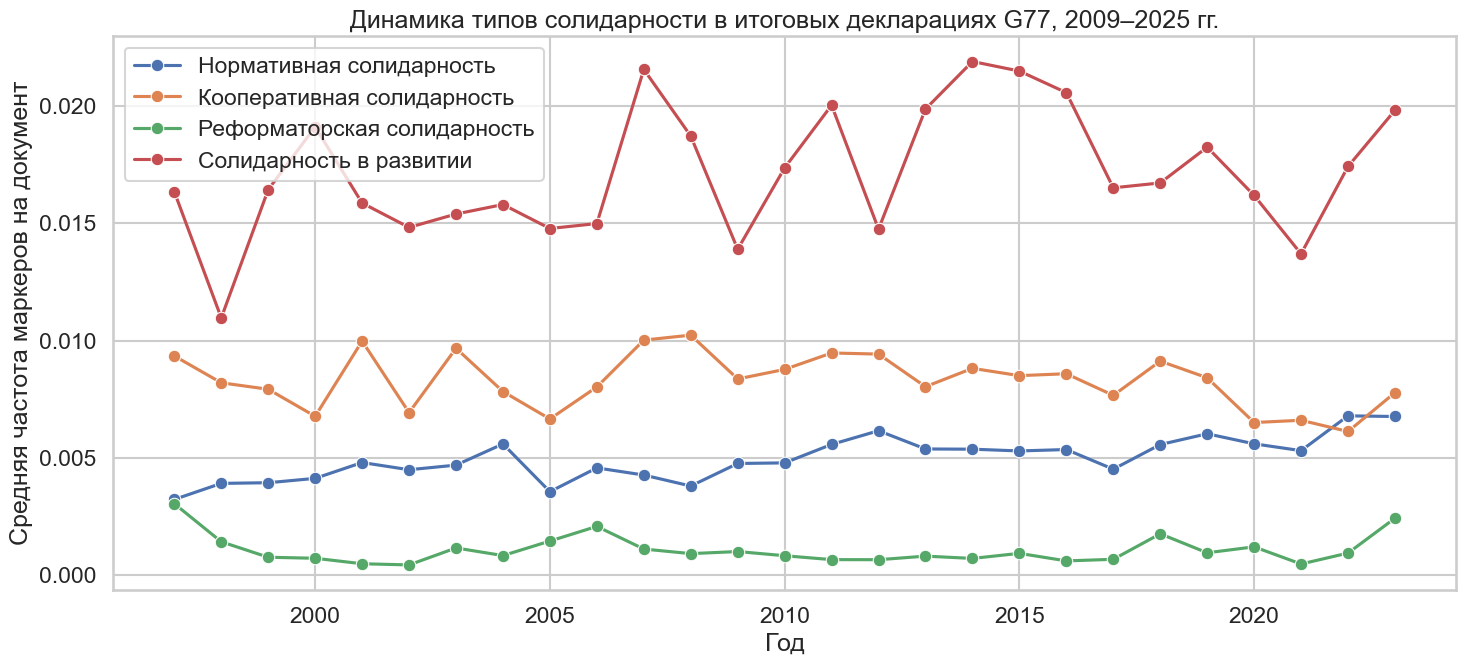

In [24]:
#агрегируем показатели по годам
by_year = (df.groupby("year")[["norms_freq", "cooperation_freq", "reform_freq", "development_freq"]].mean().reset_index().sort_values("year"))

plt.figure(figsize=(15, 7))

for col, label in [
    ("norms_freq", "Нормативная солидарность"),
    ("cooperation_freq", "Кооперативная солидарность"),
    ("reform_freq", "Реформаторская солидарность"),
    ("development_freq", "Солидарность в развитии"),
]:
    sns.lineplot(data=by_year, x="year", y=col, marker="o", label=label)

plt.title("Динамика типов солидарности в итоговых декларациях G77, 2009–2025 гг.")
plt.xlabel("Год")
plt.ylabel("Средняя частота маркеров на документ")
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация графика четырех измерений
полит солидарность формируется прежде всего вокруг повестки совместного развития и сотрудничеству + к тому же, начиная с 2021 г растет нормативное измерение, а солидарность в сотрудничестве снижена

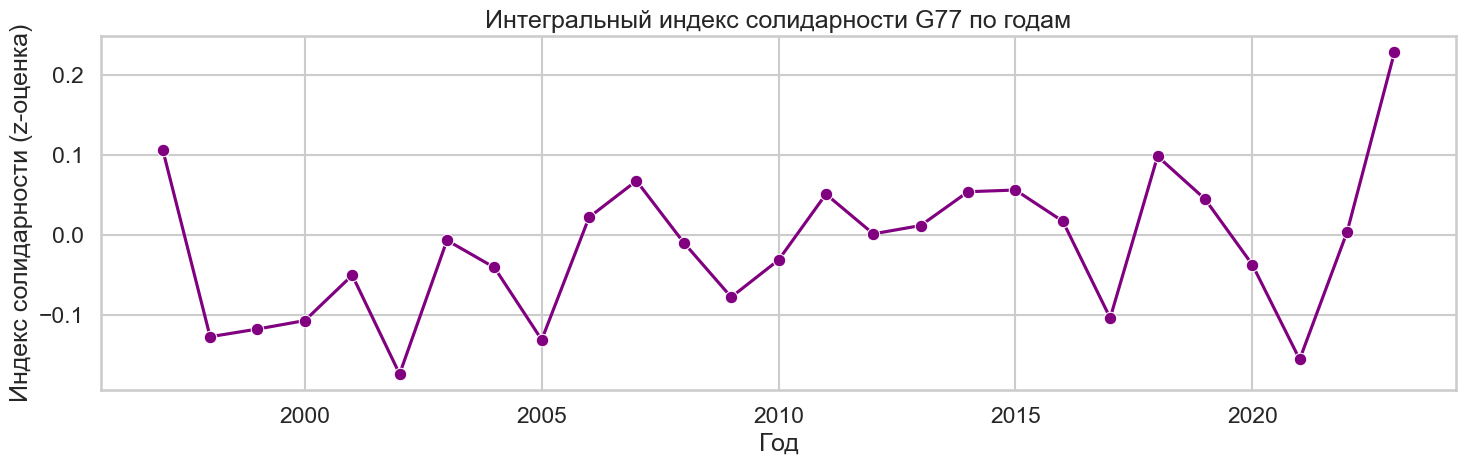

In [25]:
# агрегирование интегрального индекса по годам
by_year_index = (df.groupby("year", as_index=False)["solidarity_index"].mean().sort_values("year"))

plt.figure(figsize=(15, 5))

sns.lineplot( data=by_year_index, x="year",y="solidarity_index",marker="o", color="purple")

plt.title("Интегральный индекс солидарности G77 по годам")
plt.xlabel("Год")
plt.ylabel("Индекс солидарности (z-оценка)")
plt.tight_layout()
plt.show()

## Интерпретация интегрального индекса по годам

Волнообразная динамика --> можно интерпретировать, что растет индекс солидарности при каких-то вызовах/изменениях --> оставаясь достаточно внутреннефрагментированной

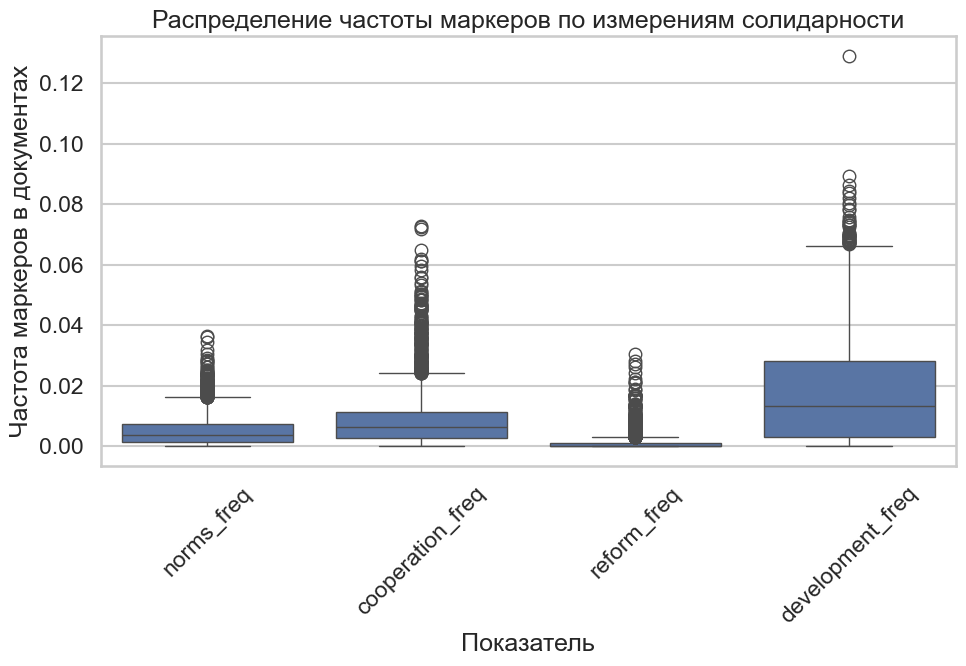

In [26]:
#приводим показатели к «длинному» формату для сравнения распределений
melted = df.melt(
    value_vars=["norms_freq", "cooperation_freq", "reform_freq", "development_freq"],
    var_name="dimension",
    value_name="freq",
)

plt.figure(figsize=(10, 7))

sns.boxplot(data=melted, x="dimension", y="freq")

plt.xticks(rotation=45)
plt.title("Распределение частоты маркеров по измерениям солидарности")
plt.xlabel("Показатель")
plt.ylabel("Частота маркеров в документах")
plt.tight_layout()
plt.show()

## Интерпретация boxplot

сильнее всего выделяется измерение development_freq: у него медиана и разброс заметно выше, чем у нормативной, кооперативной и реформаторской солидарности, что подтверждает центральное положение повестки развития

## Что измеряет контекстный блок

Здесь важна не только частота слова `solidarity`, но и то, с кем и в каких сюжетах она связывается.

Логика простая: вокруг маркеров солидарности берется контекстное окно, после чего считаются:
- разнообразие акторов (`partner_diversity`);
- разнообразие тематик (`issue_diversity`).

Если оба показателя растут, риторика становится менее декларативной и более предметной: солидарность привязывается к конкретным коалициям и повесткам.
+     Оценка контекстного разнообразия солидарности в документе:
    - сколько различных акторов оказывается в непосредственном окружении маркеров солидарности;
    - сколько различных тематических областей с ними сочетается

In [27]:
#Лексические маркеры солидарности
#по этим единицам далее извлекается локальный контекст в тексте
solidarity_markers = {
    "solidarity",
    "cooperation",
    "cooperate",
    "partnership",
    "joint",
    "consensus",
    "collective",
    "mutual",
    "coordination",
}

#Акторы, с которыми в декларациях соотносится риторика солидарности
solidarity_actors = {
    "group of 77",
    "g77",
    "china",
    "global south",
    "developing countries",
    "least developed countries",
    "small island developing states",
    "landlocked developing countries",
    "united nations",
    "general assembly",
    "ecosoc",
    "unctad",
    "wto",
    "imf",
    "world bank",
}

#Тематические области, в рамках которых артикулируется солидарность
solidarity_issues = {
    "trade",
    "investment",
    "finance",
    "debt",
    "climate",
    "adaptation",
    "mitigation",
    "security",
    "terrorism",
    "health",
    "pandemic",
    "vaccine",
    "education",
    "infrastructure",
    "technology",
    "development",
    "poverty",
    "food security",
    "human rights",
}

# Размер контекстного окна: число лемм слева и справа от маркера
context_window = 5

In [28]:
def context_indices(lemmas: list[str], window: int = context_window) -> tuple[int, int]:
    anchor_positions = [i for i, tok in enumerate(lemmas) if tok in solidarity_markers]
    if not anchor_positions:
        return 0, 0

    partners: set[str] = set()
    issues: set[str] = set()

    for pos in anchor_positions:
        left = max(0, pos - window)
        right = min(len(lemmas), pos + window + 1)
        window_tokens = lemmas[left:right]
        window_text = " ".join(window_tokens)

#фиксируем акторов, попадающих в контекст маркеров солидарности
        for actor in solidarity_actors:
            if actor in window_text:
                partners.add(actor)

#фиксируем тематические области, в которых появляется солидарность
        for issue in solidarity_issues:
            if issue in window_text:
                issues.add(issue)

    return len(partners), len(issues)


def compute_context_row(row: pd.Series) -> pd.Series:
    lemmas = row["lemmas"]
    n_partners, n_issues = context_indices(lemmas)
    return pd.Series(
        {
            "partner_diversity": n_partners,
            "issue_diversity": n_issues,
        }
    )


#добавляем контекстные показатели к корпусу
context_df = df.apply(compute_context_row, axis=1)
df = pd.concat([df, context_df], axis=1)

In [29]:
#если несколько раз уже прогон был - df = df.loc[:, ~df.columns.duplicated()]

In [30]:
print(df[["year", "partner_diversity", "issue_diversity"]])

      year  partner_diversity  issue_diversity
0     1997                  0                2
1     1997                  1                0
2     1997                  0                0
3     1997                  2                0
4     1997                  0                0
...    ...                ...              ...
3329  2023                  1                3
3331  2023                  0                0
3332  2023                  0                1
3333  2023                  0                0
3334  2023                  0                2

[3308 rows x 3 columns]


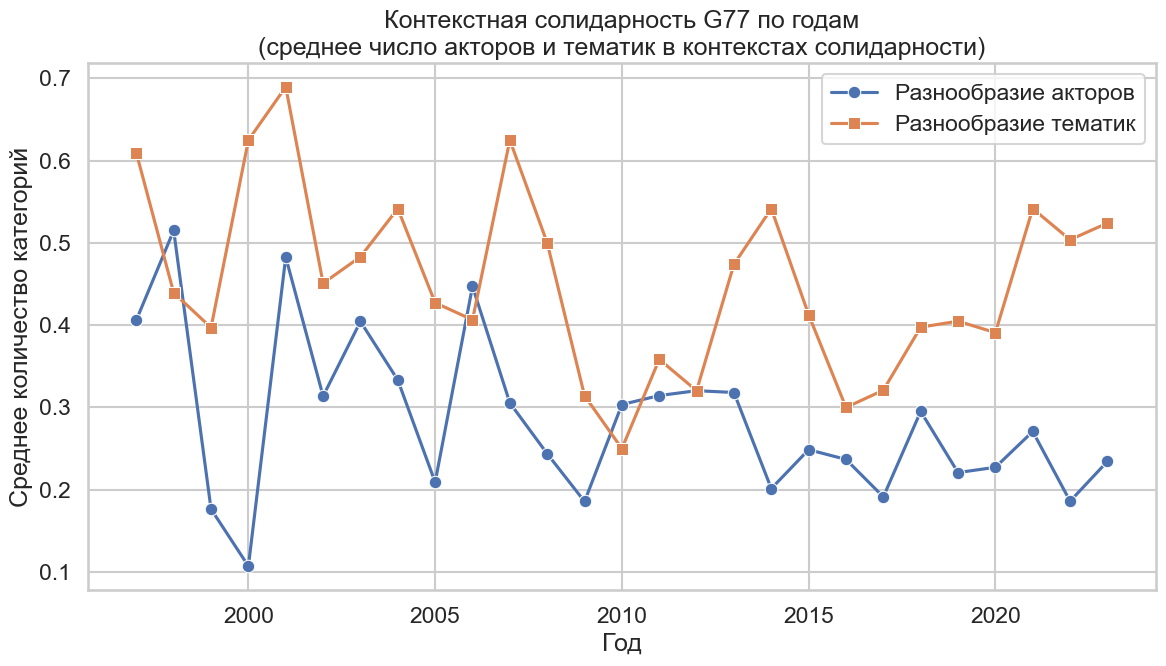

In [31]:
#агрегирование контекстных показателей по годам
context_by_year = (df.groupby("year", as_index=False)[["partner_diversity", "issue_diversity"]].mean().sort_values("year"))

#визуализация динамики контекстной солидарности
plt.figure(figsize=(12, 7))

sns.lineplot(data=context_by_year, x="year", y="partner_diversity", marker="o", label="Разнообразие акторов")

sns.lineplot(data=context_by_year, x="year", y="issue_diversity", marker="s", label="Разнообразие тематик")

plt.title(
    "Контекстная солидарность G77 по годам\n"
    "(среднее число акторов и тематик в контекстах солидарности)")
plt.xlabel("Год")
plt.ylabel("Среднее количество категорий")
plt.legend()
plt.tight_layout()
plt.show()

## Интерпретация контекстных метрик

подтверждается, что страны Группы 77+Китай все более интересует широкий спектр вопросов, в то эе время круг акторов, вокруг которых формируется повестка, остается ограниченным

## Сетевой граф

Сетевой граф показывает, какие акторы чаще оказываются в одном солидарном контексте. 
Его сильная сторона — визуализация связей, слабая — чувствительность к настройкам порога

In [32]:
#Паттерны акторов
ACTOR_PATTERNS_EN = {
    r'\bgroup of 77\b': 'G77',
    r'\bg77\b': 'G77',
    r'\bchina\b': 'China',
    r'\bglobal south\b': 'Global South',
    r'\bdeveloping countries\b': 'Developing countries',
    r'\bleast developed countries\b': 'LDCs',
    r'\bsmall island developing states\b': 'SIDS',
    r'\blandlocked developing countries\b': 'LLDCs',
    r'\bunited nations\b': 'UN',
    r'\bgeneral assembly\b': 'UNGA',
    r'\becosoc\b': 'ECOSOC',
    r'\bunctad\b': 'UNCTAD',
    r'\bwto\b': 'WTO',
    r'\bimf\b': 'IMF',
    r'\bworld bank\b': 'World Bank'
}

#Маркер солидарности
SOLIDARITY_ANCHORS_EN = {
    'solidarity', 'cooperation', 'cooperate', 'partnership', 'joint', 'consensus',
    'collective', 'mutual', 'coordination'
}


def sentence_split(text: str):
    sents = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sents if s.strip()]


def extract_actors_from_text(text: str):
    text_low = text.lower()
    actors = set()
    for pattern, name in ACTOR_PATTERNS_EN.items():
        if re.search(pattern, text_low):
            actors.add(name)
    return actors


def has_solidarity_anchor(text: str):
    t = text.lower()
    return any(anchor in t for anchor in SOLIDARITY_ANCHORS_EN)


def build_solidarity_graph(df_sub):
    G = nx.Graph()

    for _, row in df_sub.iterrows():
        text = row['text_clean']
        if not isinstance(text, str) or not text.strip():
            continue

        sents = sentence_split(text)

        for sent in sents:
            if not has_solidarity_anchor(sent):
                continue

            actors = list(extract_actors_from_text(sent))
            if len(actors) < 2:
                continue

            for a, b in combinations(sorted(actors), 2):
                if G.has_edge(a, b):
                    G[a][b]['weight'] += 1
                else:
                    G.add_edge(a, b, weight=1)

    return G


# Строим граф по всему корпусу 
G = build_solidarity_graph(df)

print('Число узлов:', G.number_of_nodes())
print('Число рёбер:', G.number_of_edges())

# Центральности
if G.number_of_nodes() > 0:
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

    centrality_df = (
        pd.DataFrame({
            'actor': list(degree_centrality.keys()),
            'degree_centrality': list(degree_centrality.values()),
            'betweenness_centrality': [betweenness_centrality[a] for a in degree_centrality.keys()]
        })
        .sort_values('degree_centrality', ascending=False)
        .reset_index(drop=True)
    )
else:
    centrality_df = pd.DataFrame(columns=['actor', 'degree_centrality', 'betweenness_centrality'])

display(centrality_df)

Число узлов: 14
Число рёбер: 74


,actor,degree_centrality,betweenness_centrality
0,China,1.000000,0.016026
1,Developing countries,1.000000,0.000000
2,G77,1.000000,0.016026
3,UN,1.000000,0.000000
4,ECOSOC,0.923077,0.157051
5,LDCs,0.846154,0.057692
6,WTO,0.846154,0.095085
7,UNCTAD,0.769231,0.038462
8,UNGA,0.769231,0.000000
9,SIDS,0.692308,0.153846


Узлы в визуализированном подграфе: 14
Рёбра (weight ≥ 1 ): 74


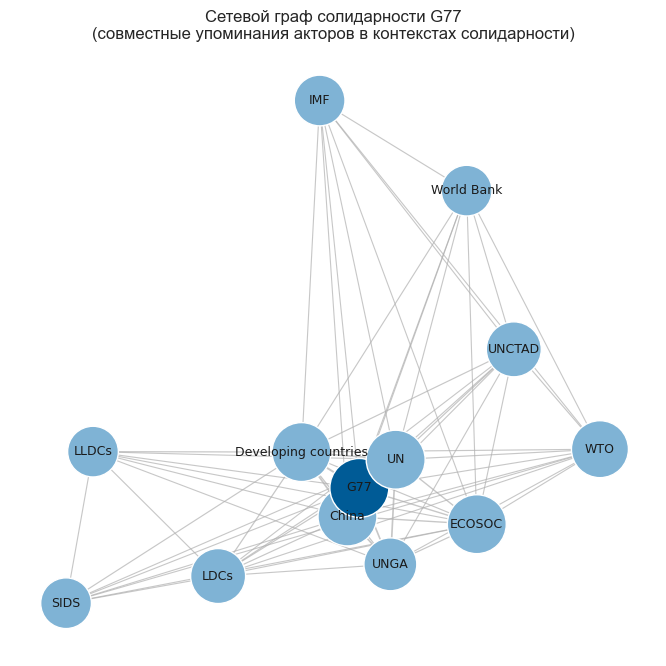

In [33]:
#Визуализация сети солидарности G77

min_weight = 1      #порог по весу ребра
top_labels = 13     #сколько акторов вообще показывать (если узлов много)

#Фильтруем рёбра и берём подграф
edges_to_keep = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight', 1) >= min_weight]
H = G.edge_subgraph(edges_to_keep).copy()

print('Узлы в визуализированном подграфе:', H.number_of_nodes())
print('Рёбра (weight ≥', min_weight, '):', H.number_of_edges())

if H.number_of_nodes() == 0:
    print('Подграф пуст — нет рёбер с весом ≥', min_weight)
else:
#Берём наиболее центральные узлы (по степени)
    degrees = dict(H.degree())
    if len(degrees) > top_labels:
        keep_nodes = sorted(degrees, key=degrees.get, reverse=True)[:top_labels]
        H = H.subgraph(keep_nodes).copy()
        degrees = dict(H.degree())

#Ставим G77 в центр, остальные вокруг
    if 'G77' in H.nodes:
        pos_init = nx.spring_layout(H, k=0.8, seed=42, weight='weight')
#G77 в центр
        pos_init['G77'] = np.array([0.0, 0.0])
#ещё раз немного распрямляем с фиксированным положением G77
        pos = nx.spring_layout(H, pos=pos_init, fixed=['G77'], k=0.8, seed=42, weight='weight')
    else:
        pos = nx.spring_layout(H, k=0.8, seed=42, weight='weight')

#Параметры стиля
    weights = [H[u][v]['weight'] for u, v in H.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.8 + 3.2 * (w / max_w) for w in weights]

    max_deg = max(degrees.values()) if degrees else 1
    node_sizes = [400 + 1400 * (deg / max_deg) for deg in degrees.values()]

#Цвета
    node_colors = []
    for n in H.nodes():
        if n == 'G77':
            node_colors.append('#005b96')  
        else:
            node_colors.append('#7fb3d5') 

    plt.figure(figsize=(7, 7))

#Рёбра
    nx.draw_networkx_edges(
        H, pos,
        width=edge_widths,
        edge_color='#B0B0B0',
        alpha=0.7
    )

#Узлы
    nx.draw_networkx_nodes(
        H, pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='white',
        linewidths=1.0
    )

#Подписи
    nx.draw_networkx_labels(
        H, pos,
        font_size=9,
        font_family='DejaVu Sans'
    )

    plt.title('Сетевой граф солидарности G77\n(совместные упоминания акторов в контекстах солидарности)',
              fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()